# 03 - Revue visuelle des cas d'erreur (RSNA)

Ce notebook affiche les cas de `eval/error_register_rsna.csv` : les erreurs réelles du meilleur prompt trouvé, `improved v10`, sur les 100 cas de `data/rsna_holdout_sample_100.txt`avec l'image

**Vérité terrain** = la vraie réponse connue (le label du dataset RSNA d'origine), par opposition à ce que le modèle a prédit


In [24]:
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve()))

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

ROOT = Path('..').resolve()
df = pd.read_csv(ROOT / 'eval' / 'error_register_rsna.csv')
df['error_type'].value_counts()

error_type
FN    23
FP     4
UA     1
Name: count, dtype: int64

In [36]:
# affiche une image avec son contexte (verite terrain, prediction, confiance, justification du modele)
def show_case(row):
    img = Image.open(ROOT / row['image_path'])

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    ax.set_title(f"case {row['case_id']} — {row['error_type']} ({row['severity']})\nreel: {row['ground_truth']} | predit: {row['prediction']} (conf {row['confidence']})")
    plt.show()

    print('justification du modele :', row['model_justification'])
    print('comment :', row['comment'])
    print('piste de correction :', row['corrective_action'])
    print()

## Faux negatifs (FN) : anomalie reelle predite normale

Les plus critiques : le modele rate une vraie anomalie. C'est le plus gros contingent d'erreurs sur RSNA (23 sur 28).

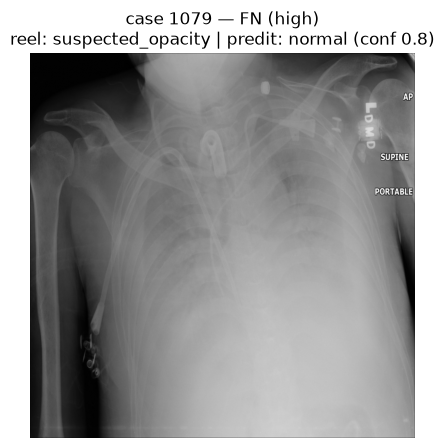

justification du modele : The left and right lung fields appear to have similar densities and textures, suggesting a normal radiographic appearance. The lung markings are present in both fields.
comment : opacité -> poumons non visibles -> erruer non évitable
piste de correction : nan



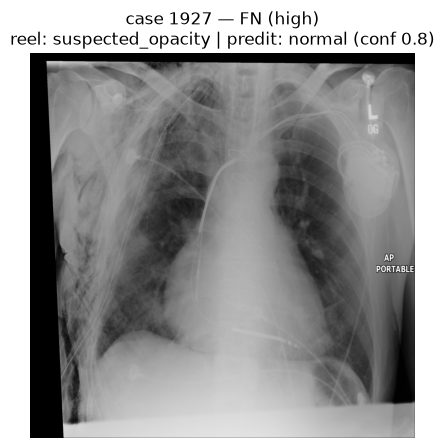

justification du modele : The left lung field appears to be more clear and well-aerated than the right lung field, which shows some increased density. This could be due to a variety of factors, including differences in lung volume, patient positioning, or underlying pathology.
comment : le modele note une densité accrue a droite mais conclut normal : incoherence justification/decision, seuil trop conservateur
piste de correction : corriger la coherence justification/decision : si une opacite est decrite, ne pas conclure normal



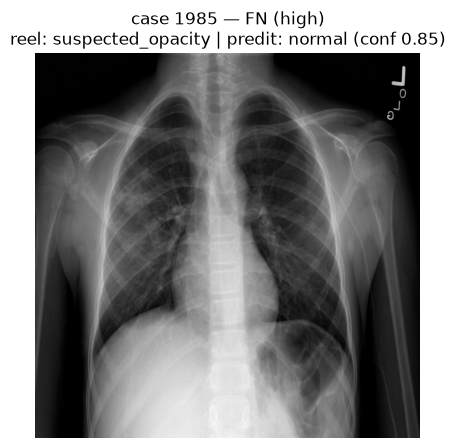

justification du modele : Based on the left-right comparison, the lung fields appear to be relatively symmetrical in terms of density and texture. There are no obvious, uniform opacities on either side.
comment : comparaison gauche/droite jugée symetrique, opacite non vue : atteinte peu marquée
piste de correction : abaisser le seuil vers normal ; prompt : ne pas conclure normal sur la seule symetrie



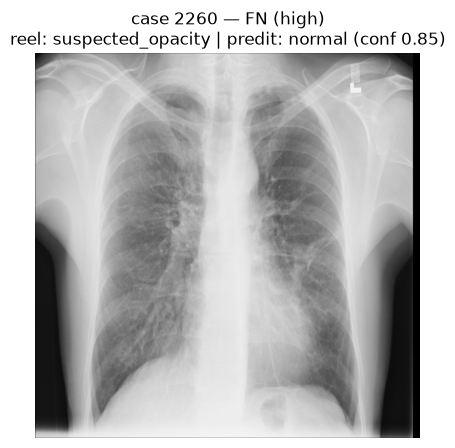

justification du modele : Based on the left-right comparison, the lung fields appear to be relatively symmetrical in terms of density and texture. There are no obvious, uniform opacities on either side.
comment : symetrie jugée normale, opacite ratée : atteinte subtile
piste de correction : abaisser le seuil vers normal ; prompt : ne pas conclure normal sur la seule symetrie



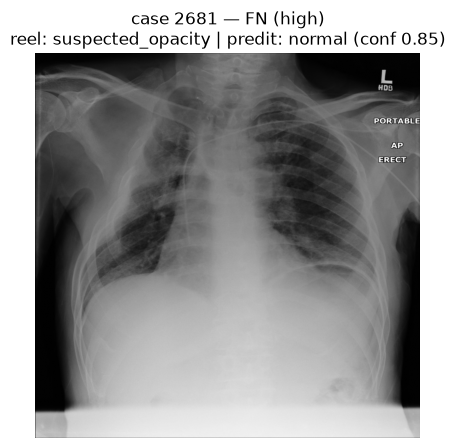

justification du modele : The left lung field appears similar in density and texture to the right lung field. The right lung field shows some increased density in the upper zone, potentially representing a consolidation or infiltrate. This could be due to a variety of factors, including infection, inflammation, or fluid accumulation.
comment : modele evoque une consolidation possible a droite mais predit normal : incoherence justification/decision
piste de correction : corriger la coherence justification/decision : si une opacite est decrite, ne pas conclure normal



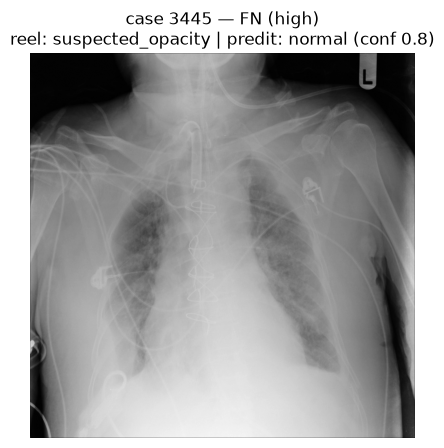

justification du modele : Based on the provided image, both the left and right lung fields appear to have similar densities and textures, suggesting a normal radiographic appearance. The lung markings are present in both fields.
comment : densites jugées similaires des deux cotes, opacite subtile ratée
piste de correction : abaisser le seuil vers normal ; prompt : ne pas conclure normal sur la seule symetrie



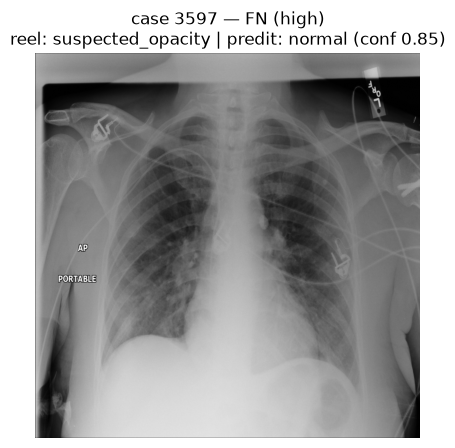

justification du modele : Based on the provided image, the left and right lung fields appear to have similar densities and textures, suggesting a normal radiographic appearance. The image is a frontal chest X-ray.
comment : poumons juges symetriques, opacite non detectée
piste de correction : abaisser le seuil vers normal ; prompt : ne pas conclure normal sur la seule symetrie



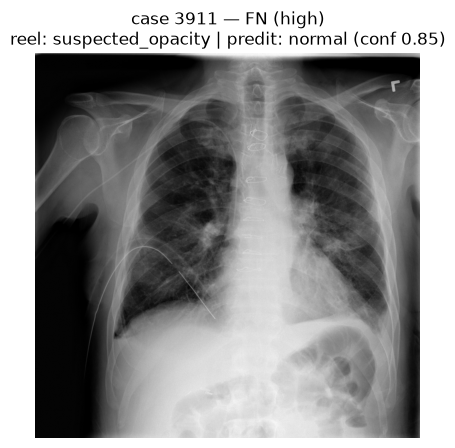

justification du modele : The left and right lung fields appear to have similar densities and textures, suggesting a normal radiographic appearance. The scattered opacities are present in both lung fields.
comment : opacites decrites dans les deux poumons mais jugées symetriques donc normal : strategie de symetrie aveugle aux atteintes bilaterales
piste de correction : prompt : une atteinte peut etre bilaterale, la symetrie ne suffit pas a exclure une opacite



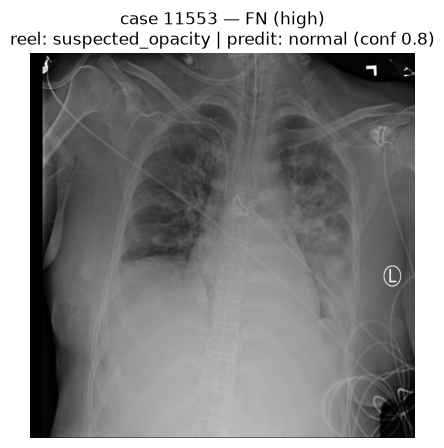

justification du modele : The left and right lung fields appear to have similar densities and textures, suggesting a normal radiographic appearance. However, there is some increased density in the lower lung zones of both lungs, which could be due to atelectasis or other minor findings.
comment : densite accrue bilaterale (bases) notée mais jugée normale : la symetrie n'exclut pas une opacite si les deux cotes sont atteints
piste de correction : prompt : une atteinte peut etre bilaterale, la symetrie ne suffit pas a exclure une opacite



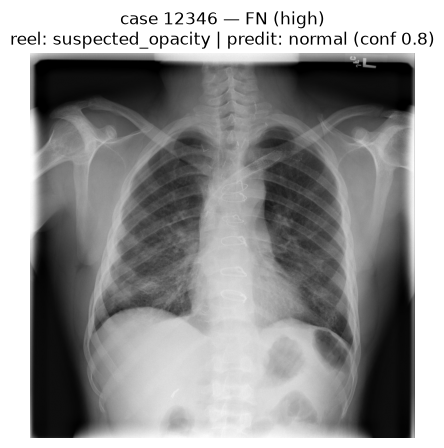

justification du modele : Based on the left-right comparison, the lung fields appear to be relatively symmetrical in terms of density and texture. There are no obvious, uniform opacities on either side.
comment : symetrie jugée normale, opacite ratée
piste de correction : abaisser le seuil vers normal ; prompt : ne pas conclure normal sur la seule symetrie



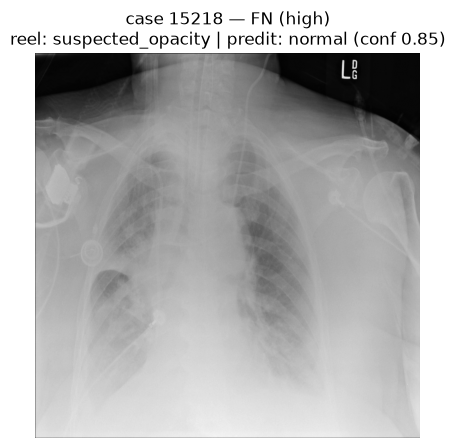

justification du modele : Based on the provided image, both the left and right lung fields appear to have similar densities and textures, suggesting a normal radiographic appearance. The lung markings are present in both fields.
comment : densites similaires des deux cotes, opacite subtile ratée
piste de correction : abaisser le seuil vers normal ; prompt : ne pas conclure normal sur la seule symetrie



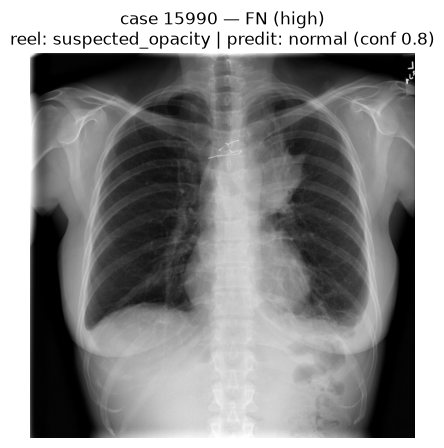

justification du modele : Based on the provided image, both the left and right lung fields appear to have similar densities and textures, suggesting a normal lung appearance. There are no obvious areas of increased density or consolidation that would indicate a suspected opacity.
comment : aucune zone dense reperée, opacite ratée : cas subtil
piste de correction : abaisser le seuil vers normal ; prompt : ne pas conclure normal sur la seule symetrie



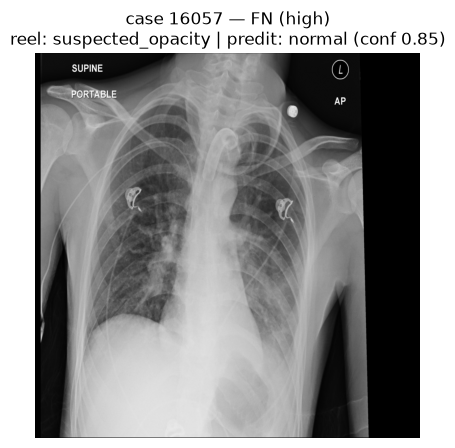

justification du modele : Based on the provided image, both the left and right lung fields appear to have similar densities and textures, suggesting a normal radiographic appearance. The lung markings are consistent on both sides.
comment : poumons juges symetriques, opacite non vue
piste de correction : abaisser le seuil vers normal ; prompt : ne pas conclure normal sur la seule symetrie



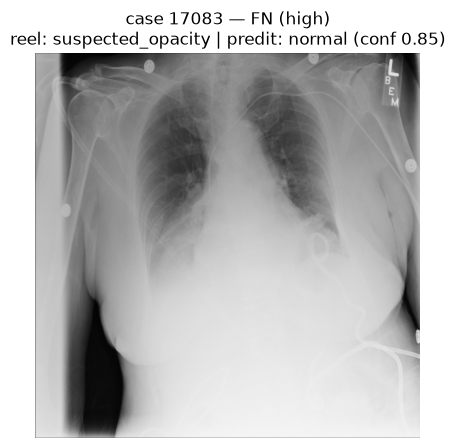

justification du modele : The left and right lung fields appear to have similar densities and textures, suggesting a normal radiographic appearance. The lung markings are present in both fields.
comment : densites similaires, opacite subtile ratée
piste de correction : abaisser le seuil vers normal ; prompt : ne pas conclure normal sur la seule symetrie



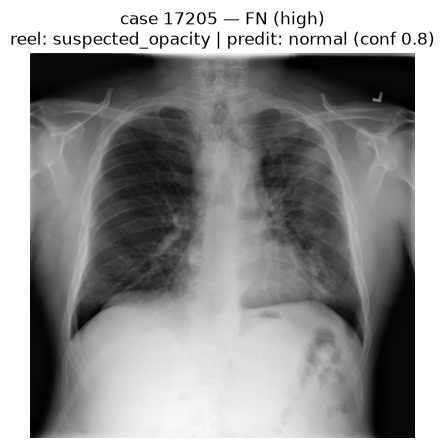

justification du modele : The left lung field appears to have a slightly increased density compared to the right lung field. This could be due to a variety of factors, including differences in lung tissue density or the position of the patient during the scan. However, without further information, it is difficult to determine the exact cause.
comment : densite accrue a gauche notée puis ecartée (positionnement) : hesitation tranchée a tort en normal
piste de correction : corriger la coherence justification/decision : si une opacite est decrite, ne pas conclure normal



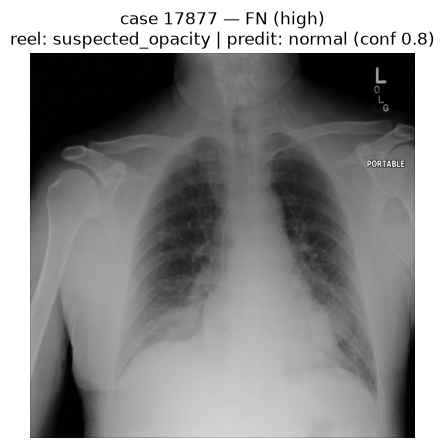

justification du modele : Based on the provided image, both the left and right lung fields appear to have similar densities and textures, suggesting a normal radiographic appearance. The lung markings are consistent on both sides.
comment : symetrie jugée normale, opacite ratée
piste de correction : abaisser le seuil vers normal ; prompt : ne pas conclure normal sur la seule symetrie



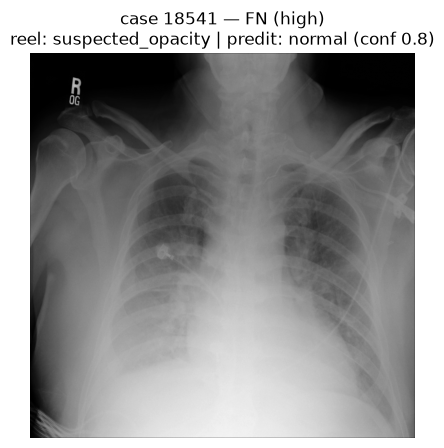

justification du modele : The left and right lung fields appear to have similar densities and textures, suggesting a normal radiographic appearance. The lung markings are present in both fields.
comment : densites similaires des deux cotes, opacite ratée
piste de correction : abaisser le seuil vers normal ; prompt : ne pas conclure normal sur la seule symetrie



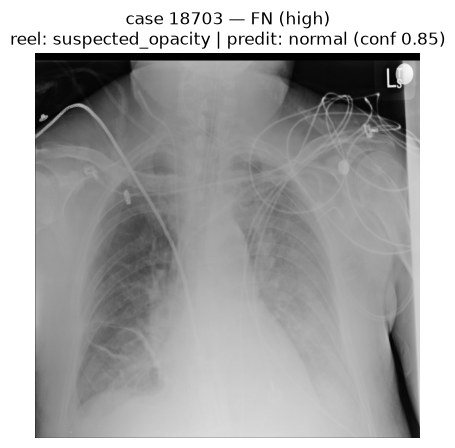

justification du modele : Based on the provided image, both the left and right lung fields appear to have similar densities and textures, suggesting a normal radiographic appearance. The lung markings are visible in both fields.
comment : poumons juges symetriques, opacite non detectée
piste de correction : abaisser le seuil vers normal ; prompt : ne pas conclure normal sur la seule symetrie



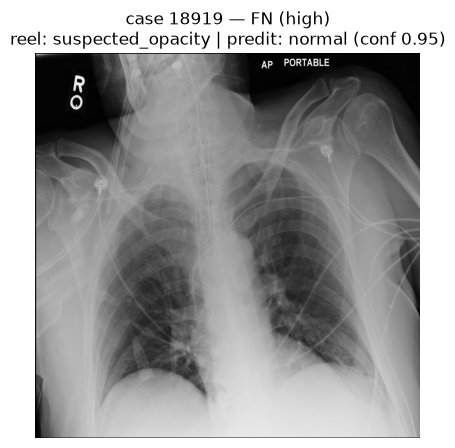

justification du modele : Based on the provided image, both the left and right lung fields appear to have similar densities and textures, suggesting a normal radiographic appearance. The lung markings are consistent on both sides.
comment : juge normal avec forte confiance (0.95), opacite ratée : sur-confiance sur un cas difficile
piste de correction : abaisser le seuil vers normal ; prompt : ne pas conclure normal sur la seule symetrie



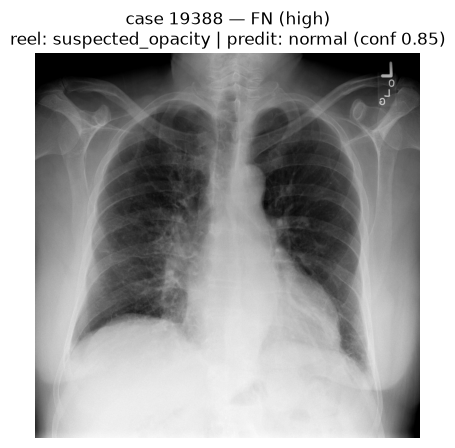

justification du modele : Based on the provided image, both the left and right lung fields appear to have similar densities and textures, suggesting a normal radiographic appearance. The lung markings are consistent on both sides.
comment : symetrie jugée normale, opacite ratée
piste de correction : abaisser le seuil vers normal ; prompt : ne pas conclure normal sur la seule symetrie



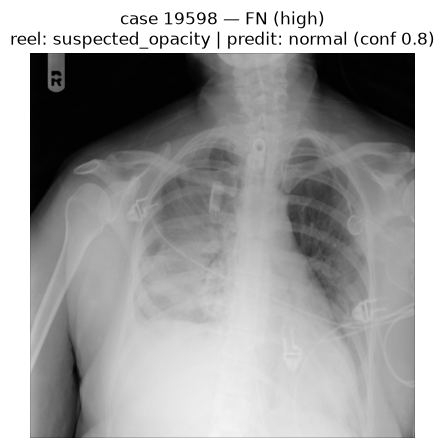

justification du modele : The left lung field appears clear and well-aerated, while the right lung field shows a hazy opacity in the lower portion. This could be due to fluid or consolidation.
comment : opacite hazy decrite dans la base droite (fluide/consolidation) mais predite normale : incoherence nette, faux negatif evitable
piste de correction : corriger la coherence justification/decision : si une opacite est decrite, ne pas conclure normal



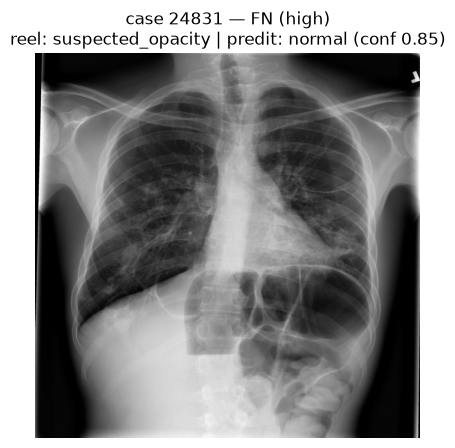

justification du modele : Based on the left-right comparison, the lung fields appear to be relatively symmetrical in terms of density and texture. This suggests a normal radiographic appearance.
comment : comparaison gauche/droite jugée symetrique, opacite ratée
piste de correction : abaisser le seuil vers normal ; prompt : ne pas conclure normal sur la seule symetrie



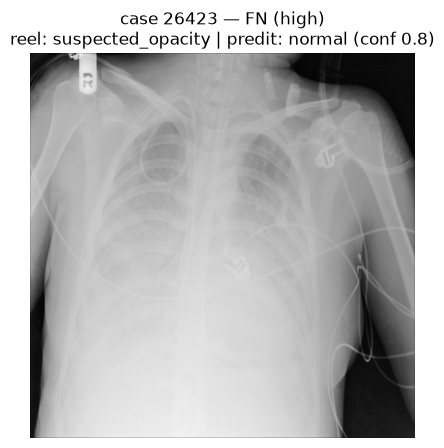

justification du modele : Based on the provided image, both lung fields appear to have similar densities and textures, suggesting a normal radiographic appearance. The image is a frontal chest X-ray.
comment : densites similaires, opacite subtile ratée
piste de correction : abaisser le seuil vers normal ; prompt : ne pas conclure normal sur la seule symetrie



In [37]:
for _, row in df[df['error_type'] == 'FN'].iterrows():
    show_case(row)

## Faux positifs (FP) : poumon normal predit suspect

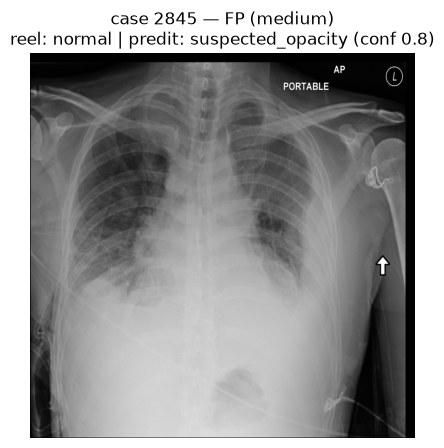

justification du modele : The left lung field appears denser than the right lung field, suggesting a possible opacity. The right lung field appears relatively clear.
comment : asymetrie de densite (gauche plus dense) lue comme opacite sur un poumon sain : verifier positionnement/materiel externe
piste de correction : verifier materiel externe/positionnement avant de conclure opacite ; ne pas confondre asymetrie de densite et opacite



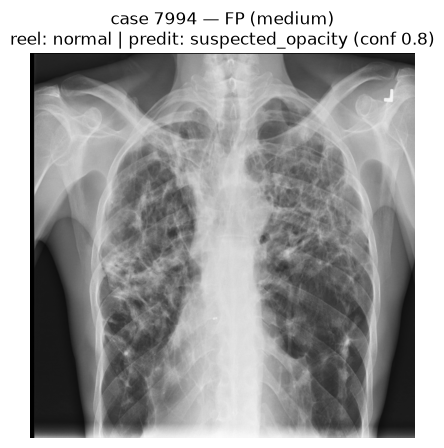

justification du modele : The right lung field appears more dense than the left lung field, suggesting a possible opacity. The right lung field shows increased opacity.
comment : densite accrue a droite sur poumon normal interpretée comme opacite : fausse alerte sur variation de densite
piste de correction : verifier materiel externe/positionnement avant de conclure opacite ; ne pas confondre asymetrie de densite et opacite



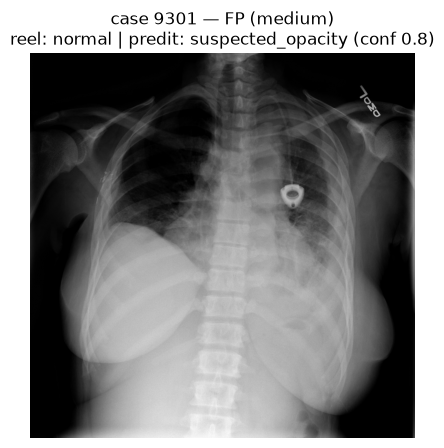

justification du modele : The left lung field appears denser than the right lung field, suggesting a possible opacity in the left lung. The right lung field shows increased opacity.
comment : asymetrie gauche/droite sur poumon sain prise pour une opacite
piste de correction : verifier materiel externe/positionnement avant de conclure opacite ; ne pas confondre asymetrie de densite et opacite



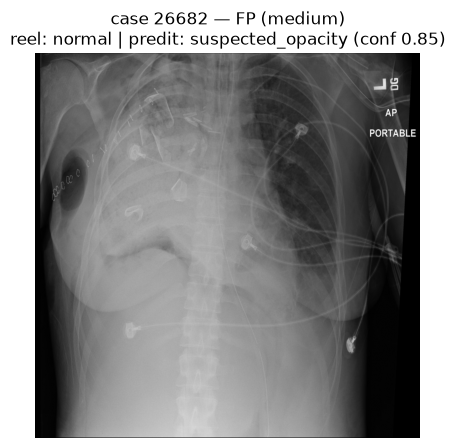

justification du modele : The right lung field is much denser than the left lung field, with a large opacity obscuring the right lung markings. This suggests a possible right lung opacity.
comment : opacite droite decrite avec forte confiance sur un cas normal : verifier materiel externe/positionnement, faux positif marque
piste de correction : verifier materiel externe/positionnement avant de conclure opacite ; ne pas confondre asymetrie de densite et opacite



In [38]:
for _, row in df[df['error_type'] == 'FP'].iterrows():
    show_case(row)

## Incertitude acceptable (UA) : repli sur uncertain

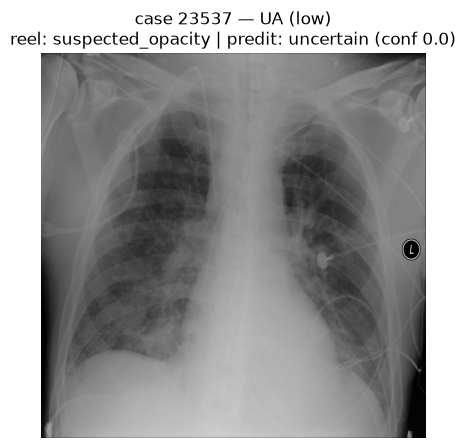

justification du modele : nan
comment : pas de justification, repli sur incertain : pas de sur-diagnostic mais opacite réelle manquée
piste de correction : repli sur incertain acceptable ; pas d'action



In [39]:
for _, row in df[df['error_type'] == 'UA'].iterrows():
    show_case(row)